# Wine Style Clustering — 02: Embeddings & UMAP

**Input:** `data/processed/wines_model.csv`  
**Output:** `data/processed/wines_umap.csv` — embeddings + 2D UMAP coordinates

Steps:
1. Load modelling subset (Still/Unknown, Red + White + Rosé)
2. Build description input — LLM-cleaned text, optionally append grape variety
3. Encode with fine-tuned SentenceTransformer
4. Sanity check — synonym similarity on full sentences
5. Reduce to 2D with UMAP for visualisation

---

## 0. Setup

In [133]:
import os
os.chdir(os.path.expanduser('~/Documents/wine-style-clustering'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.size': 12,
})

RED   = '#8B1A2A'
WHITE = '#C9A84C'
ROSE  = '#E8A598'

MODEL_PATH = 'models/style-finetuned/final'
DATA_PATH  = 'data/processed/wines_model.csv'
EMB_PATH   = 'models/embeddings.npy'
UMAP_PATH  = 'models/umap_2d.npy'

print('Ready.')


Ready.


## 1. Load data

In [134]:
df = pd.read_csv(DATA_PATH)
print(f'Loaded: {len(df):,} rows')
print(df['Colour'].value_counts())
df.head(2)


Loaded: 19,241 rows
Colour
Red      8783
White    8364
Rosé     2094
Name: count, dtype: int64


,url,title,description,score,Producer,Vintage,Wine Type,Colour,Country,Region,...,Sweetness,Closure,Alcohol,Body,Oak,Grapes,description_clean,grape_normalized,desc_len,oak_normalized
0,https://www.decanter.com/wine-reviews/italy/pi...,"Mauro Veglio, Barolo Arborina, La Morra, Piedm...","The estate’s first single-site bottling, in 19...",93.0,Mauro Veglio,2022.0,Still,Red,Italy,Piedmont,...,Dry,Cork,14.50%,Full,Yes,100% Nebbiolo,"It opens sumptuously with cinnamon, tobacco, s...",nebbiolo,53,oaked
1,https://www.decanter.com/wine-reviews/italy/pi...,"Fratelli Alessandria, Barolo Gramolere, Monfor...",Pristine fruit and a clear expression of place...,94.0,Fratelli Alessandria,2022.0,Still,Red,Italy,Piedmont,...,Dry,Cork,14.50%,Full,Oaked,100% Nebbiolo,Pristine fruit and a clear expression of place...,nebbiolo,49,oaked


In [135]:
# wines_model.csv already filters Still/Unknown — this is a safety check
df = df[df['Wine Type'].isin(['Still', 'Unknown'])].reset_index(drop=True)
print(f'After Still/Unknown filter: {len(df):,}')
print(df['Colour'].value_counts())


After Still/Unknown filter: 19,241
Colour
Red      8783
White    8364
Rosé     2094
Name: count, dtype: int64


## 2. Build description input

Base: LLM-cleaned `description_clean` (winemaking, provenance and editorial noise removed).  
Toggle `APPEND_GRAPE` to compare embedding quality with/without grape variety appended.


In [136]:
APPEND_GRAPE = True  # True → append 'Grape: {grape_normalized}.' to each description

def build_input(row):
    text = str(row['description_clean']) if pd.notna(row['description_clean']) else str(row['description'])
    if APPEND_GRAPE:
        grape = str(row.get('grape_normalized', ''))
        if grape and grape not in ('nan', 'None', ''):
            text = f'{text} Grape: {grape}.'
    return text

df['description_input'] = df.apply(build_input, axis=1)
print(f'APPEND_GRAPE = {APPEND_GRAPE} | {len(df):,} inputs built')
print()
for i in range(2):
    print(f'[{i}] {df["description_input"].iloc[i]}')
    print()


APPEND_GRAPE = True | 19,241 inputs built

[0] It opens sumptuously with cinnamon, tobacco, strawberry and plum. An easy, steady flow of sweet berries expands across the palate with grace. Long, silky tannins keep pace. Seductive oak is neatly nestled in. This distinguishes itself for its beautifully finessed texture and underlying freshness. Will give plenty of pleasure over the next decade. Grape: nebbiolo.

[1] Pristine fruit and a clear expression of place emerge in the balsamic mint, pepper and cardamom which imbue strawberry and macerated raspberry. This is generous in fruit while elegantly weighted, with tannins that are gracious, velvety and almost chocolatey, and the vitality to persist for at least a decade. Grape: nebbiolo.



## 3. Load fine-tuned model

In [137]:
model = SentenceTransformer(MODEL_PATH)
print(f'Model:     {MODEL_PATH}')
print(f'Embedding: {model.get_sentence_embedding_dimension()}D')


Model:     models/style-finetuned/final
Embedding: 384D


## 4. Encode descriptions

Embeddings cached to `models/embeddings.npy` after first run.  
Delete cache to re-encode after changing `APPEND_GRAPE` or model.


In [138]:
if os.path.exists(EMB_PATH):
    embeddings = np.load(EMB_PATH)
    print(f'Loaded cached embeddings: {embeddings.shape}')
else:
    embeddings = model.encode(
        df['description_input'].tolist(),
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    np.save(EMB_PATH, embeddings)
    print(f'Encoded and saved: {embeddings.shape}')


Batches:   0%|          | 0/301 [00:00<?, ?it/s]

Encoded and saved: (19241, 384)


## 5. Sanity check — synonym similarity

Verify the model captures wine style similarity, not just lexical overlap.  
Synonym pairs (dried cherry / kirsch, sous bois / forest floor) should score > 0.65.  
The negative control (red fruit vs oyster shell) should score < 0.4.


In [139]:
pairs = [
    ('The wine shows dried cherry and red berry fruit with earthy notes',
     'Classic kirsch and wild strawberry with a hint of forest floor'),
    ('Notes of forest floor and damp earth with mushroom complexity',
     'Sous bois character with truffle and autumn leaves'),
    ('Rich blackcurrant fruit with cedar and tobacco',
     'Cassis and dark plum with graphite minerality'),
    # Negative control — red fruit vs mineral white
    ('Dried cherry and raspberry with silky tannins',
     'Oyster shell minerality with crisp citrus and saline finish'),
]

print(f'{"Pair":<35} {"Similarity":>10}  Note')
print('-' * 65)
for a, b in pairs:
    ea  = model.encode(a, normalize_embeddings=True)
    eb  = model.encode(b, normalize_embeddings=True)
    sim = float(cos_sim(ea, eb))
    note = '✓ synonyms' if sim > 0.65 else '✓ negatives distant'
    print(f'{a[:32]}...  {sim:>10.3f}  {note}')


Pair                                Similarity  Note
-----------------------------------------------------------------
The wine shows dried cherry and ...       0.793  ✓ synonyms
Notes of forest floor and damp e...       0.705  ✓ synonyms
Rich blackcurrant fruit with ced...       0.777  ✓ synonyms
Dried cherry and raspberry with ...       0.228  ✓ negatives distant


## 6. UMAP — reduce to 2D

Projection cached to `models/umap_2d.npy` after first run.

In [140]:
if os.path.exists(UMAP_PATH):
    umap_2d = np.load(UMAP_PATH)
    print(f'Loaded cached UMAP: {umap_2d.shape}')
else:
    reducer = umap.UMAP(
        n_components=2, n_neighbors=15, min_dist=0.05,
        metric='cosine', random_state=42, verbose=True,
    )
    umap_2d = reducer.fit_transform(embeddings)
    np.save(UMAP_PATH, umap_2d)
    print(f'UMAP computed and saved: {umap_2d.shape}')

df['umap_x'] = umap_2d[:, 0]
df['umap_y'] = umap_2d[:, 1]


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.05, n_jobs=1, random_state=42, verbose=True)
Mon Apr 13 22:04:28 2026 Construct fuzzy simplicial set
Mon Apr 13 22:04:28 2026 Finding Nearest Neighbors
Mon Apr 13 22:04:28 2026 Building RP forest with 12 trees
Mon Apr 13 22:04:28 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	 3  /  14
	 4  /  14
	Stopping threshold met -- exiting after 4 iterations
Mon Apr 13 22:04:29 2026 Finished Nearest Neighbor Search
Mon Apr 13 22:04:29 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr 13 22:04:37 2026 Finished embedding
UMAP computed and saved: (19241, 2)


## 7. Visualise

fig, ax = plt.subplots(figsize=(10, 7))

for colour, color, label in [
    ('Red',   RED,   'Red wines'),
    ('White', WHITE, 'White wines'),
    ('Rosé',  ROSE,  'Rosé wines'),
]:
    mask = df['Colour'] == colour
    ax.scatter(
        df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
        c=color, alpha=0.35, s=6, label=label, rasterized=True
    )

ax.set_title('Wine descriptions in semantic space (UMAP 2D)', fontsize=14, pad=12)
ax.set_xlabel('UMAP dimension 1')
ax.set_ylabel('UMAP dimension 2')
ax.legend(markerscale=4, fontsize=11)
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.savefig('results/figures/02_umap.png', dpi=150, bbox_inches='tight')
plt.show()


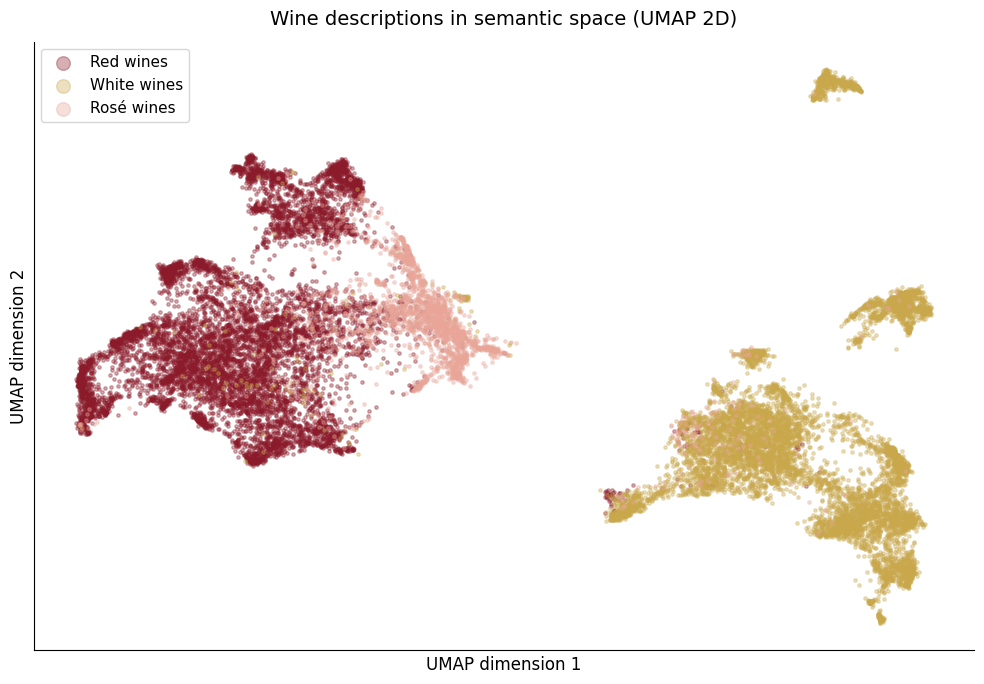

In [141]:
ROSE = '#E8A598'

fig, ax = plt.subplots(figsize=(10, 7))

for colour, color, label in [
    ('Red',  RED,   'Red wines'),
    ('White', WHITE, 'White wines'),
    ('Rosé',  ROSE,  'Rosé wines'),
]:
    mask = df['Colour'] == colour
    ax.scatter(
        df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
        c=color, alpha=0.35, s=6, label=label, rasterized=True
    )

ax.set_title('Wine descriptions in semantic space (UMAP 2D)', fontsize=14, pad=12)
ax.set_xlabel('UMAP dimension 1')
ax.set_ylabel('UMAP dimension 2')
ax.legend(markerscale=4, fontsize=11)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig('results/figures/02_umap_red_white.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Save

In [142]:
df.to_csv('data/processed/wines_umap.csv', index=False)
print(f'Saved wines_umap.csv — {len(df):,} rows')
print(f'Columns: description_input, umap_x, umap_y')

Saved wines_umap.csv — 19,241 rows
Columns: description_input, umap_x, umap_y


---

## Summary

| Step | Detail |
|------|--------|
| Model | Fine-tuned SentenceTransformer, 384-dim (`models/style-finetuned/final`) |
| Wine types | Still + Unknown (Sparkling and Fortified excluded) |
| Colours | Red, White, Rosé |
| Input text | LLM-cleaned `description_clean` |
| Grape signal | Optional — toggle `APPEND_GRAPE` |
| UMAP params | n_neighbors=15, min_dist=0.05, cosine metric |

**Next:** `03_clustering.ipynb`
